# BEAD Random Forest — Stratified Ensemble (EPA Method)

Inspired by the EPA's streamflow duration assessment, which builds **separate Random Forest models per regional subset** and combines predictions via voting.

**Approach**: Stratify by **technology type** (dominant deployment technology per project), train a separate RF per stratum, and combine via averaging (regression analog of majority voting).

- **Target**: `log1p(funding_per_location)` — same as `bead_rf_final.ipynb`
- **Features**: 5 features (same as final model minus `technology`, which is the stratification key)
- **1500 trees per model** (matching EPA spec)
- **Ensemble methods**: Routed (matching technology model) vs Voted (average across all stratum models)

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='broadband-data')
print('Connected to BigQuery: broadband-data')

Connected to BigQuery: broadband-data


In [2]:
# Load all data sources (same as bead_rf_final)
df_projects = client.query("""
SELECT project_id, state, bead_support, estimated_miles_aerial_fiber,
       estimated_miles_buried_fiber, estimated_jobs, project_type, priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT project_id, COUNT(*) AS funded_locations,
       SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].value AS FLOAT64) AS technology,
       AVG(CAST(low_latency AS INT64)) AS avg_latency
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}
df_nbm = client.query("""
SELECT state, COUNT(DISTINCT frn) AS state_num_providers
FROM `broadband-data.fcc_nbm.nbm_hive` GROUP BY state
""").to_dataframe()
df_nbm['state'] = df_nbm['state'].map(state_name_to_abbr)
df_nbm = df_nbm.dropna(subset=['state'])

df_state_pop = client.query("""
SELECT stateabbr AS state, SUM(pop2020) AS state_population
FROM `broadband-data.fcc_block_level_pop.us2020` GROUP BY stateabbr
""").to_dataframe()

print(f'Projects: {df_projects.shape}, Locations: {df_locations.shape}')

Projects: (5251, 8), Locations: (5228, 4)


In [3]:
# Merge + feature engineering (same pipeline as bead_rf_final)
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')
df = df.merge(df_state_pop, on='state', how='left')

df['funded_locations'] = df['funded_locations'].fillna(0)
df['technology'] = df['technology'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)
df['state_population'] = df['state_population'].fillna(0)

df['total_fiber_miles'] = df['estimated_miles_aerial_fiber'].fillna(0) + df['estimated_miles_buried_fiber'].fillna(0)
df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['miles_per_location'] = df['miles_per_location'].fillna(0)
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)
df['jobs_per_location'] = df['jobs_per_location'].fillna(0)

df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])
low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]

df['log_funding'] = np.log1p(df['funding_per_location'])
print(f'Samples after outlier removal: {df.shape[0]}')

Samples after outlier removal: 4962


## Technology Distribution
Examine technology group sizes and merge small strata (< 50 samples) into an "Other" group.

In [4]:
# Technology code mapping (FCC technology codes)
tech_labels = {
    0: 'Unknown/Missing',
    10: 'Copper Wire', 40: 'DOCSIS/HFC', 50: 'Fiber (FTTP)',
    60: 'Satellite', 70: 'Fixed Wireless', 71: 'Licensed Fixed Wireless',
    72: 'Licensed-by-Rule Fixed Wireless'
}

tech_counts = df['technology'].value_counts().sort_values(ascending=False)
print('Technology distribution:')
for code, count in tech_counts.items():
    label = tech_labels.get(int(code), f'Code {int(code)}')
    print(f'  {label} ({int(code)}): {count} projects ({count/len(df)*100:.1f}%)')

# Group small strata (< 50 samples) into 'Other'
MIN_STRATUM_SIZE = 50
small_techs = tech_counts[tech_counts < MIN_STRATUM_SIZE].index.tolist()
if small_techs:
    print(f'\nGrouping {len(small_techs)} small strata into "Other" (code -1): {[int(t) for t in small_techs]}')
    df['tech_group'] = df['technology'].apply(lambda x: -1 if x in small_techs else x)
else:
    df['tech_group'] = df['technology']

group_counts = df['tech_group'].value_counts().sort_values(ascending=False)
print(f'\nFinal strata ({len(group_counts)} groups):')
for code, count in group_counts.items():
    label = tech_labels.get(int(code), 'Other' if code == -1 else f'Code {int(code)}')
    print(f'  {label}: {count} projects')

Technology distribution:
  Fiber (FTTP) (50): 2430 projects (49.0%)
  Code 61 (61): 1831 projects (36.9%)
  Licensed Fixed Wireless (71): 461 projects (9.3%)
  Licensed-by-Rule Fixed Wireless (72): 145 projects (2.9%)
  DOCSIS/HFC (40): 62 projects (1.2%)
  Fixed Wireless (70): 29 projects (0.6%)
  Unknown/Missing (0): 2 projects (0.0%)
  Satellite (60): 2 projects (0.0%)

Grouping 3 small strata into "Other" (code -1): [70, 0, 60]

Final strata (6 groups):
  Fiber (FTTP): 2430 projects
  Code 61: 1831 projects
  Licensed Fixed Wireless: 461 projects
  Licensed-by-Rule Fixed Wireless: 145 projects
  DOCSIS/HFC: 62 projects
  Other: 33 projects


## Train Stratified Models
One Random Forest per technology group, 1500 trees each (EPA spec), 80/20 split within each stratum.

In [5]:
# Features: same as bead_rf_final minus technology (stratification key)
feature_cols = [
    'miles_per_location',
    'jobs_per_location',
    'state_population',
    'total_fiber_miles',
    'state_num_providers',
]

# Train one RF per technology group
stratum_models = {}
stratum_metrics = {}
stratum_test_data = {}

tech_groups = sorted(df['tech_group'].unique())

print(f'Training {len(tech_groups)} stratum models with 1500 trees each...\n')

for tech in tech_groups:
    mask = df['tech_group'] == tech
    df_stratum = df[mask]
    
    X_s = df_stratum[feature_cols].fillna(0)
    y_s = df_stratum['log_funding']
    
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
    
    rf_s = RandomForestRegressor(n_estimators=1500, min_samples_split=5, random_state=42, n_jobs=-1)
    rf_s.fit(X_tr, y_tr)
    y_pred_s = rf_s.predict(X_te)
    
    r2 = r2_score(y_te, y_pred_s)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred_s)))
    mae = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred_s))
    
    label = tech_labels.get(int(tech), 'Other' if tech == -1 else f'Code {int(tech)}')
    stratum_models[tech] = rf_s
    stratum_metrics[tech] = {'r2': r2, 'rmse': rmse, 'mae': mae, 'n_train': len(X_tr), 'n_test': len(X_te)}
    stratum_test_data[tech] = (X_te, y_te, y_pred_s)
    
    print(f'{label} (n={len(df_stratum)}, train={len(X_tr)}, test={len(X_te)})')
    print(f'  R²={r2:.4f}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}\n')

print('All stratum models trained.')

Training 6 stratum models with 1500 trees each...



Other (n=33, train=26, test=7)
  R²=0.7333  RMSE=$2,742  MAE=$1,811



DOCSIS/HFC (n=62, train=49, test=13)
  R²=0.6472  RMSE=$4,320  MAE=$3,522



Fiber (FTTP) (n=2430, train=1944, test=486)
  R²=0.4616  RMSE=$2,855  MAE=$2,063



Code 61 (n=1831, train=1464, test=367)
  R²=0.6354  RMSE=$329  MAE=$189



Licensed Fixed Wireless (n=461, train=368, test=93)
  R²=0.5516  RMSE=$1,604  MAE=$1,133



Licensed-by-Rule Fixed Wireless (n=145, train=116, test=29)
  R²=0.1804  RMSE=$2,299  MAE=$1,322

All stratum models trained.


## Ensemble Prediction on Global Test Set
Compare three approaches:
1. **Global RF** — single model on all data (baseline)
2. **Routed** — use only the matching technology stratum model
3. **Voted (Averaged)** — average predictions from all stratum models

In [6]:
# Global 80/20 split for fair comparison
X_all = df[feature_cols].fillna(0)
y_all = df['log_funding']
tech_all = df['tech_group']

X_train, X_test, y_train, y_test, tech_train, tech_test = train_test_split(
    X_all, y_all, tech_all, test_size=0.2, random_state=42
)

# 1. Global RF baseline (1500 trees for fair comparison)
rf_global = RandomForestRegressor(n_estimators=1500, min_samples_split=5, random_state=42, n_jobs=-1)
rf_global.fit(X_train, y_train)
y_pred_global = rf_global.predict(X_test)

# 2. Routed ensemble: use the matching stratum model for each test project
y_pred_routed = np.zeros(len(X_test))
for i, (idx, row) in enumerate(X_test.iterrows()):
    tech = tech_test.loc[idx]
    if tech in stratum_models:
        y_pred_routed[i] = stratum_models[tech].predict(row.values.reshape(1, -1))[0]
    else:
        y_pred_routed[i] = rf_global.predict(row.values.reshape(1, -1))[0]

# 3. Voted (averaged) ensemble: average predictions from all stratum models
y_pred_voted = np.zeros(len(X_test))
for tech, model in stratum_models.items():
    y_pred_voted += model.predict(X_test)
y_pred_voted /= len(stratum_models)

print('Ensemble predictions computed.')

Ensemble predictions computed.


## Results Comparison

In [7]:
# Compare all three approaches
def compute_metrics(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    rmse_real = np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))
    mae_real = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    return {'Method': label, 'R² (log)': r2, 'RMSE (log)': rmse_log, 'RMSE ($)': rmse_real, 'MAE ($)': mae_real}

results = pd.DataFrame([
    compute_metrics(y_test, y_pred_global, 'Global RF (baseline)'),
    compute_metrics(y_test, y_pred_routed, 'Routed Ensemble'),
    compute_metrics(y_test, y_pred_voted, 'Voted (Averaged) Ensemble'),
])
results = results.set_index('Method')

print('=== Model Comparison ===')
print(results.to_string(float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'${x:,.0f}'))

# Highlight best
best_r2 = results['R² (log)'].idxmax()
best_rmse = results['RMSE ($)'].idxmin()
print(f'\nBest R²: {best_r2} ({results.loc[best_r2, "R² (log)"]:.4f})')
print(f'Best RMSE: {best_rmse} (${results.loc[best_rmse, "RMSE ($)"]:,.0f})')

=== Model Comparison ===
                           R² (log)  RMSE (log)  RMSE ($)  MAE ($)
Method                                                            
Global RF (baseline)         0.6922      0.5353    $2,585   $1,490
Routed Ensemble              0.8757      0.3401    $1,672     $911
Voted (Averaged) Ensemble    0.3616      0.7709    $3,454   $2,301

Best R²: Routed Ensemble (0.8757)
Best RMSE: Routed Ensemble ($1,672)


## Per-Stratum Performance Plots

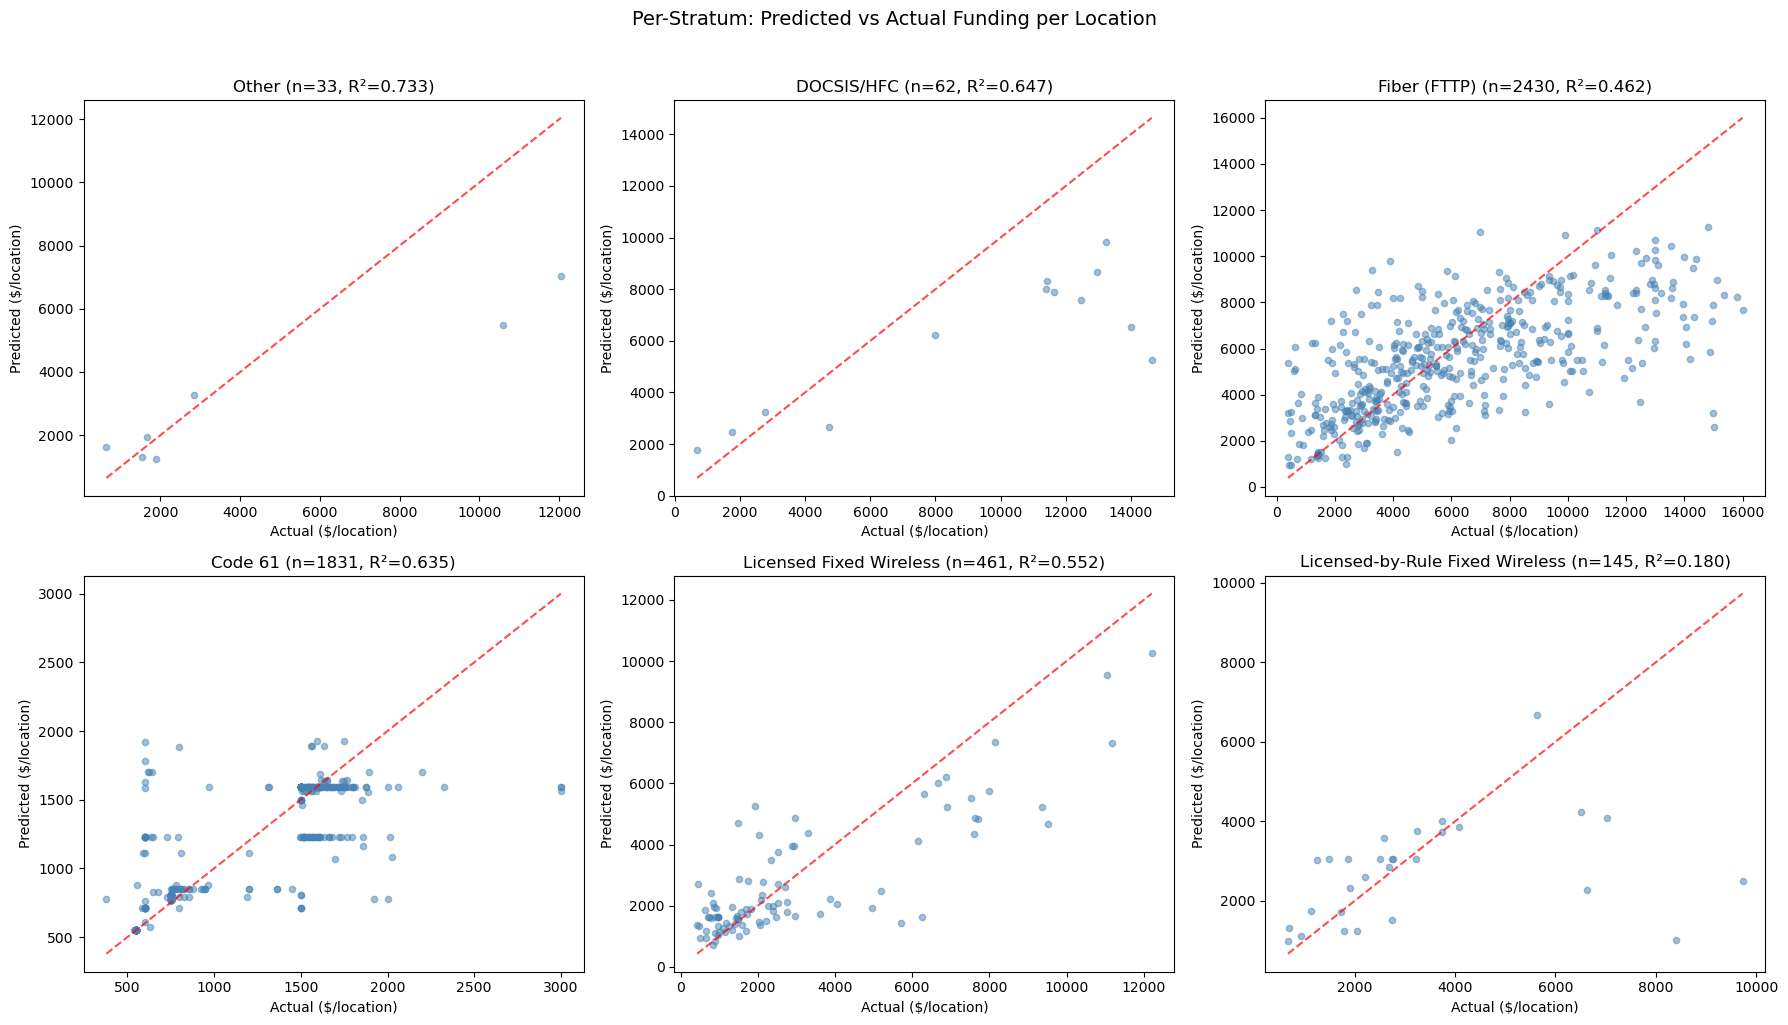

In [8]:
# Predicted vs Actual for each technology group (from within-stratum test sets)
n_strata = len(stratum_test_data)
n_cols = min(3, n_strata)
n_rows = (n_strata + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)

for i, tech in enumerate(sorted(stratum_test_data.keys())):
    ax = axes[i // n_cols][i % n_cols]
    X_te, y_te, y_pred_s = stratum_test_data[tech]
    
    actual_real = np.expm1(y_te)
    pred_real = np.expm1(y_pred_s)
    r2 = stratum_metrics[tech]['r2']
    n = stratum_metrics[tech]['n_train'] + stratum_metrics[tech]['n_test']
    
    label = tech_labels.get(int(tech), 'Other' if tech == -1 else f'Code {int(tech)}')
    
    ax.scatter(actual_real, pred_real, alpha=0.5, s=20, color='steelblue')
    lims = [min(actual_real.min(), pred_real.min()), max(actual_real.max(), pred_real.max())]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlabel('Actual ($/location)')
    ax.set_ylabel('Predicted ($/location)')
    ax.set_title(f'{label} (n={n}, R²={r2:.3f})')

# Hide unused subplots
for j in range(n_strata, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].set_visible(False)

plt.suptitle('Per-Stratum: Predicted vs Actual Funding per Location', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Feature Importance per Stratum

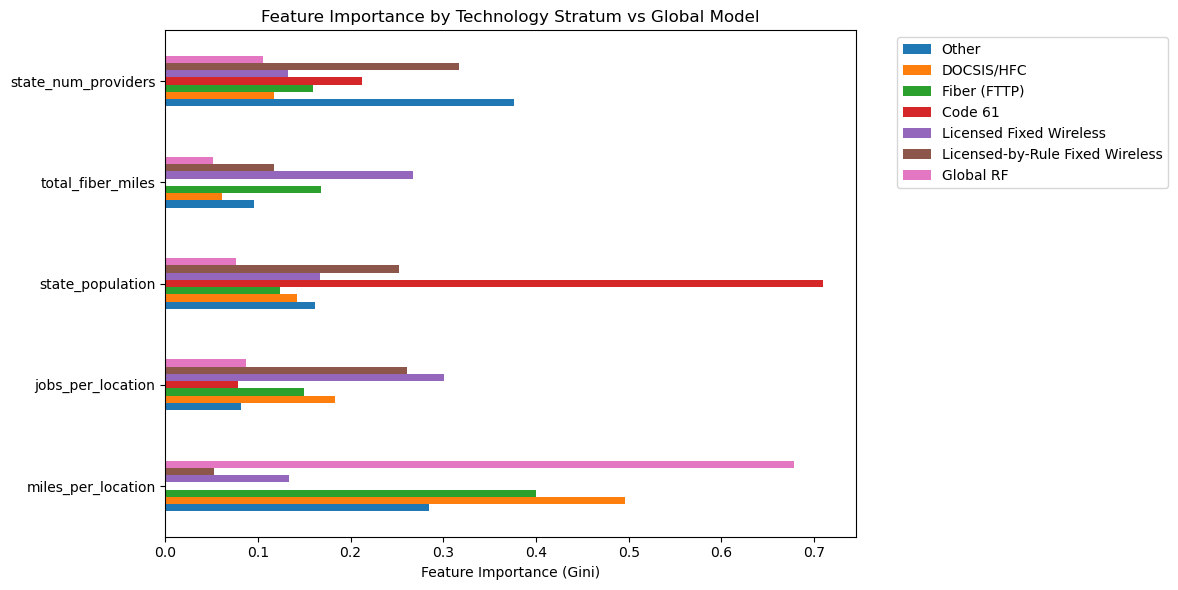

Feature importance by stratum:
                      Other  DOCSIS/HFC  Fiber (FTTP)  Code 61  Licensed Fixed Wireless  Licensed-by-Rule Fixed Wireless  Global RF
miles_per_location   0.2842      0.4960        0.3998   0.0000                   0.1330                           0.0527     0.6786
jobs_per_location    0.0822      0.1827        0.1500   0.0787                   0.3002                           0.2612     0.0874
state_population     0.1617      0.1425        0.1235   0.7095                   0.1669                           0.2521     0.0766
total_fiber_miles    0.0953      0.0615        0.1677   0.0000                   0.2675                           0.1173     0.0520
state_num_providers  0.3767      0.1173        0.1590   0.2119                   0.1322                           0.3166     0.1053


In [9]:
# Side-by-side feature importance bar charts per technology group
importance_df = pd.DataFrame({
    tech_labels.get(int(tech), 'Other' if tech == -1 else f'Code {int(tech)}'): 
    pd.Series(model.feature_importances_, index=feature_cols)
    for tech, model in stratum_models.items()
})

# Add global model for comparison
importance_df['Global RF'] = pd.Series(rf_global.feature_importances_, index=feature_cols)

fig, ax = plt.subplots(figsize=(12, 6))
importance_df.plot.barh(ax=ax)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance by Technology Stratum vs Global Model')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Feature importance by stratum:')
print(importance_df.round(4).to_string())

## SHAP Analysis per Stratum
TreeExplainer for each stratum model — shows how feature effects differ by technology type.

In [10]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap
print(f'SHAP version: {shap.__version__}')

SHAP version: 0.52.0



--- Other ---


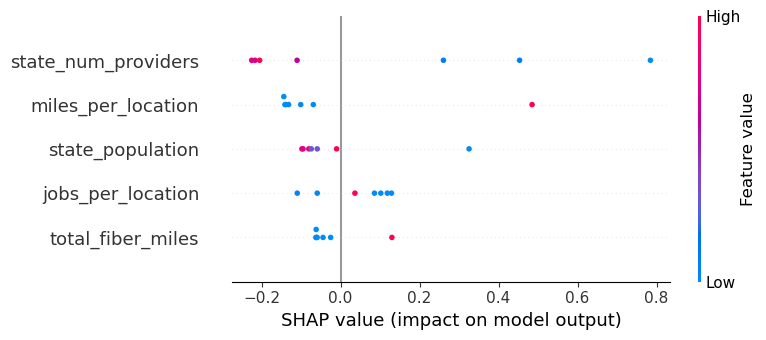


--- DOCSIS/HFC ---


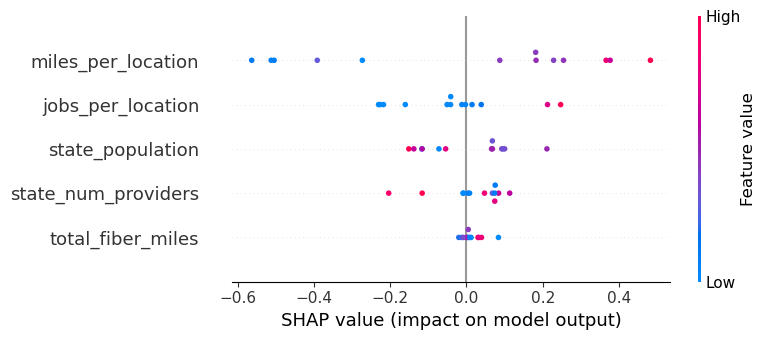


--- Fiber (FTTP) ---


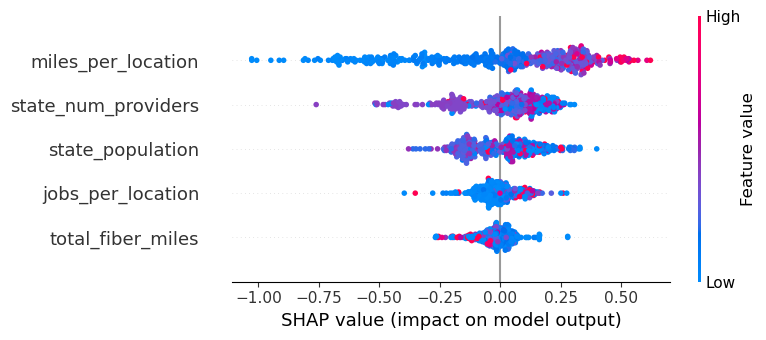


--- Code 61 ---


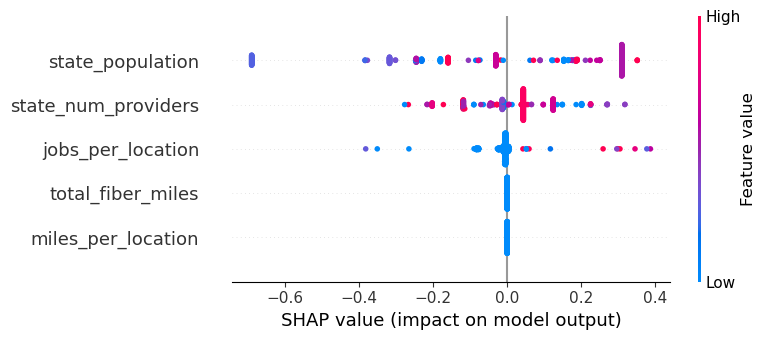


--- Licensed Fixed Wireless ---


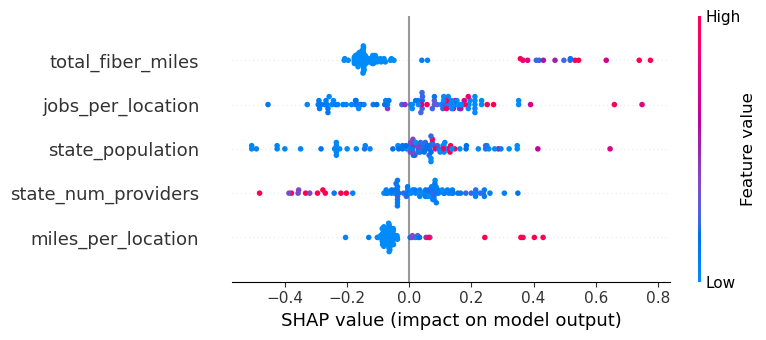


--- Licensed-by-Rule Fixed Wireless ---


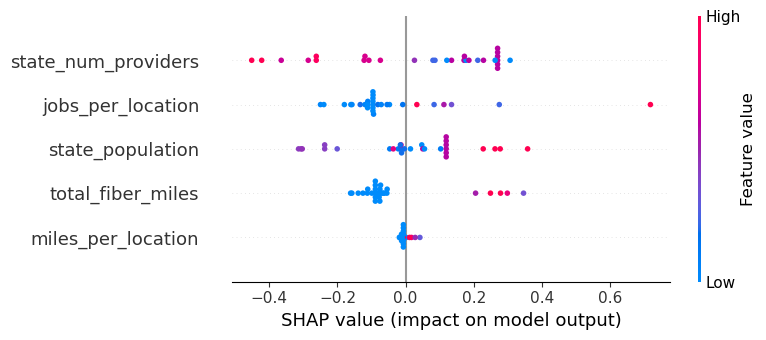


SHAP analysis complete for all strata.


In [11]:
# SHAP summary plot per stratum
shap_values_per_stratum = {}

for tech in sorted(stratum_models.keys()):
    model = stratum_models[tech]
    X_te = stratum_test_data[tech][0]
    
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_te)
    shap_values_per_stratum[tech] = (sv, X_te)
    
    label = tech_labels.get(int(tech), 'Other' if tech == -1 else f'Code {int(tech)}')
    print(f'\n--- {label} ---')
    shap.summary_plot(sv, X_te, feature_names=feature_cols, show=True)

print('\nSHAP analysis complete for all strata.')

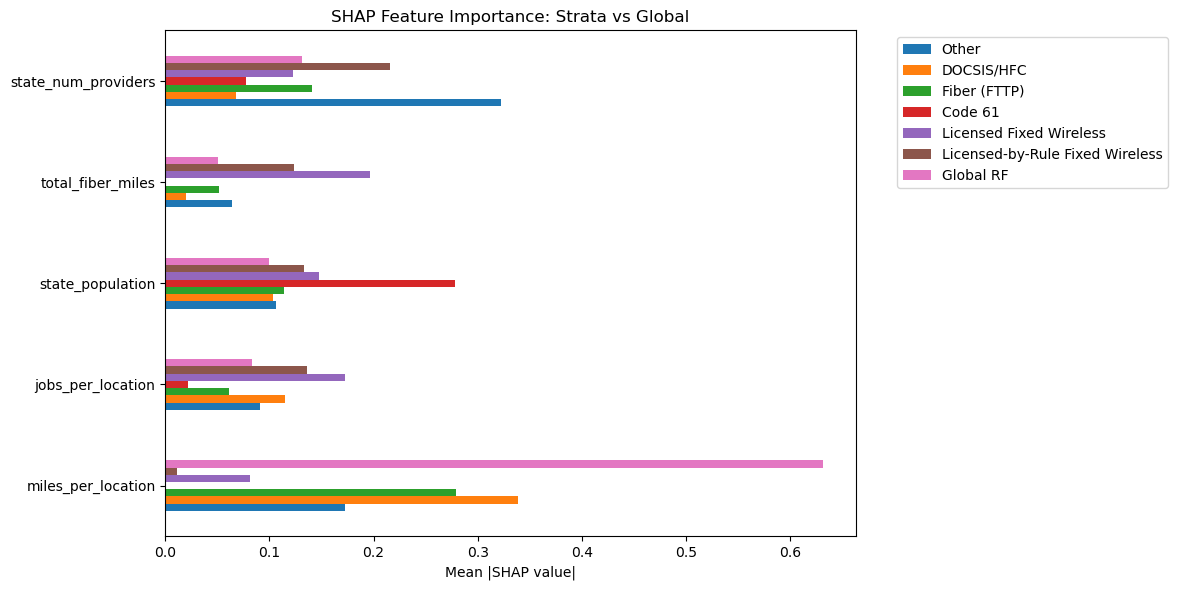

Mean |SHAP| by stratum:
                      Other  DOCSIS/HFC  Fiber (FTTP)  Code 61  Licensed Fixed Wireless  Licensed-by-Rule Fixed Wireless  Global RF
miles_per_location   0.1730      0.3388        0.2794   0.0000                   0.0815                           0.0114     0.6314
jobs_per_location    0.0913      0.1150        0.0608   0.0214                   0.1722                           0.1365     0.0828
state_population     0.1062      0.1039        0.1142   0.2785                   0.1477                           0.1336     0.0995
total_fiber_miles    0.0637      0.0200        0.0515   0.0000                   0.1964                           0.1237     0.0509
state_num_providers  0.3223      0.0682        0.1406   0.0776                   0.1228                           0.2158     0.1316


In [12]:
# SHAP bar plot comparison: mean |SHAP| per feature across strata
shap_importance = pd.DataFrame({
    tech_labels.get(int(tech), 'Other' if tech == -1 else f'Code {int(tech)}'): 
    pd.Series(np.abs(sv).mean(axis=0), index=feature_cols)
    for tech, (sv, _) in shap_values_per_stratum.items()
})

# Also compute SHAP for global model
global_explainer = shap.TreeExplainer(rf_global)
global_shap = global_explainer.shap_values(X_test)
shap_importance['Global RF'] = pd.Series(np.abs(global_shap).mean(axis=0), index=feature_cols)

fig, ax = plt.subplots(figsize=(12, 6))
shap_importance.plot.barh(ax=ax)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance: Strata vs Global')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Mean |SHAP| by stratum:')
print(shap_importance.round(4).to_string())

## Comparison Summary
Does stratification by technology improve over the global model?

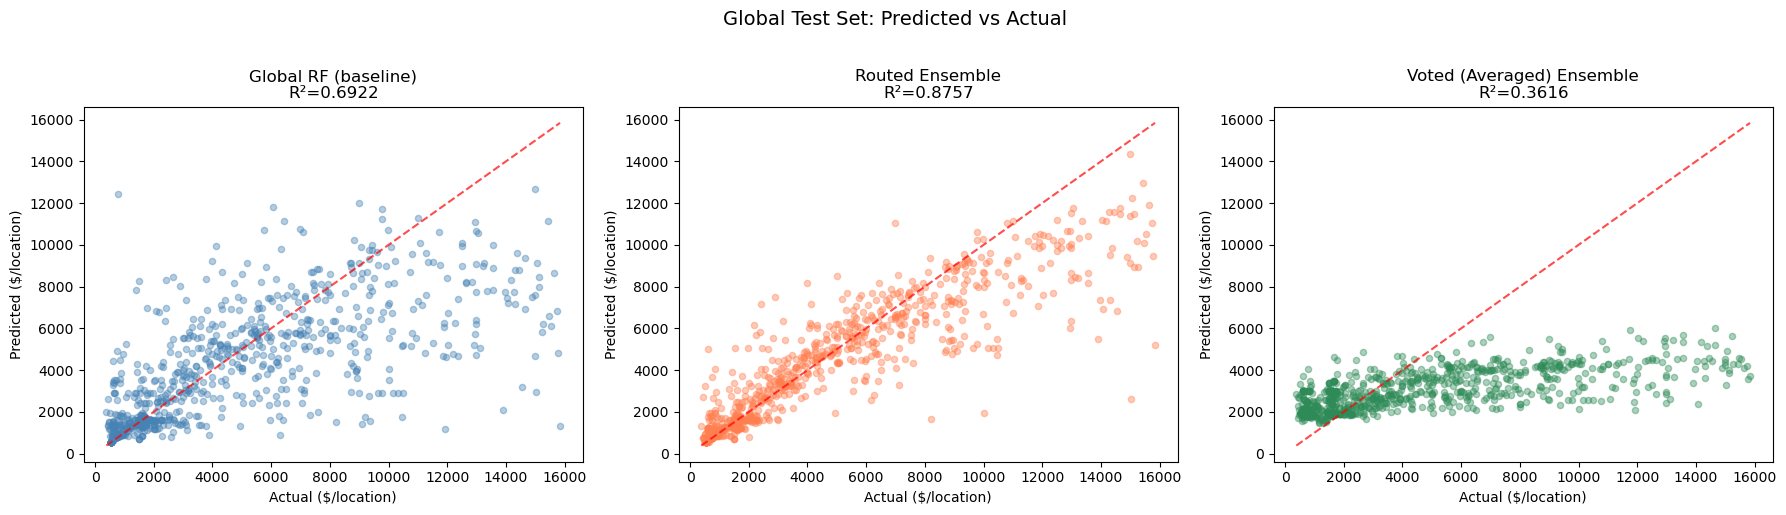


=== STRATIFICATION ASSESSMENT ===
Global RF R²:          0.6922
Routed Ensemble R²:    0.8757 (+0.1835)
Voted Ensemble R²:     0.3616 (-0.3306)

Stratification IMPROVES prediction. Best: Routed ensemble.
Technology groups have distinct cost structures that benefit from specialized models.

=== Per-Stratum Performance ===
                                 N (train)  N (test)     R²  RMSE ($)  MAE ($)
Other                                   26    7.0000 0.7333     2,742    1,811
DOCSIS/HFC                              49        13 0.6472     4,320    3,522
Fiber (FTTP)                         1,944       486 0.4616     2,855    2,063
Code 61                              1,464       367 0.6354       329      189
Licensed Fixed Wireless                368        93 0.5516     1,604    1,133
Licensed-by-Rule Fixed Wireless        116        29 0.1804     2,299    1,322


In [13]:
# Final comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ['Global RF (baseline)', 'Routed Ensemble', 'Voted (Averaged) Ensemble']
preds = [y_pred_global, y_pred_routed, y_pred_voted]
colors = ['steelblue', 'coral', 'seagreen']

for ax, method, y_p, color in zip(axes, methods, preds, colors):
    actual_real = np.expm1(y_test)
    pred_real = np.expm1(y_p)
    r2 = r2_score(y_test, y_p)
    
    ax.scatter(actual_real, pred_real, alpha=0.4, s=20, color=color)
    lims = [min(actual_real.min(), pred_real.min()), max(actual_real.max(), pred_real.max())]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlabel('Actual ($/location)')
    ax.set_ylabel('Predicted ($/location)')
    ax.set_title(f'{method}\nR²={r2:.4f}')

plt.suptitle('Global Test Set: Predicted vs Actual', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print('\n=== STRATIFICATION ASSESSMENT ===')
r2_global = r2_score(y_test, y_pred_global)
r2_routed = r2_score(y_test, y_pred_routed)
r2_voted = r2_score(y_test, y_pred_voted)

print(f'Global RF R²:          {r2_global:.4f}')
print(f'Routed Ensemble R²:    {r2_routed:.4f} ({r2_routed - r2_global:+.4f})')
print(f'Voted Ensemble R²:     {r2_voted:.4f} ({r2_voted - r2_global:+.4f})')

if r2_routed > r2_global or r2_voted > r2_global:
    best = 'Routed' if r2_routed > r2_voted else 'Voted'
    print(f'\nStratification IMPROVES prediction. Best: {best} ensemble.')
    print('Technology groups have distinct cost structures that benefit from specialized models.')
else:
    print(f'\nStratification does NOT improve over the global model.')
    print('The global RF already captures technology-driven cost differences via the technology feature.')

# Per-stratum summary table
print('\n=== Per-Stratum Performance ===')
stratum_summary = pd.DataFrame(stratum_metrics).T
stratum_summary.index = [tech_labels.get(int(t), 'Other' if t == -1 else f'Code {int(t)}') for t in stratum_summary.index]
stratum_summary = stratum_summary[['n_train', 'n_test', 'r2', 'rmse', 'mae']]
stratum_summary.columns = ['N (train)', 'N (test)', 'R²', 'RMSE ($)', 'MAE ($)']
print(stratum_summary.to_string(float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'{x:,.0f}'))